# Compare Value And Neighbour Models

This notebook scans `logs/` for `test.py` benchmark outputs and compares the released value model against the released neighbour model across beam widths.

Expected inputs:
- one or more `logs/test_*.json` files for the value model
- one or more `logs/test_*.json` files for the neighbour model

The released defaults are:
- value model `1776548012`
- neighbour model `1776581286`


In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
ROOT = Path.cwd()
LOG_DIR = ROOT / 'logs'
if not LOG_DIR.exists() and (ROOT.parent / 'logs').exists():
    LOG_DIR = ROOT.parent / 'logs'

VALUE_MODEL_ID = 1776548012
NEIGHBOUR_MODEL_ID = 1776581286

log_dir_display = LOG_DIR.name
if LOG_DIR.is_relative_to(ROOT):
    log_dir_display = str(LOG_DIR.relative_to(ROOT))

print(f'Using logs from: {log_dir_display}')


Using logs from: logs


In [3]:
TEST_LOG_RE = re.compile(
    r"test_(?P<model_name>.+)_(?P<model_id>\d+)_(?P<checkpoint>best|\d+)_B(?P<beam>\d+)(?P<compile>_compile)?\.json$"
)


def load_test_runs(model_id, log_dir=LOG_DIR):
    runs = []
    for path in sorted(log_dir.glob('test_*.json')):
        match = TEST_LOG_RE.match(path.name)
        if match is None:
            continue
        if int(match.group('model_id')) != int(model_id):
            continue
        payload = json.loads(path.read_text())
        solved = [row for row in payload if row.get('solution_length') is not None]
        if not solved:
            continue
        runs.append(
            {
                'path': path.name,
                'beam_width': int(match.group('beam')),
                'compile': bool(match.group('compile')),
                'model_name': match.group('model_name'),
                'avg_solution_length': float(np.mean([row['solution_length'] for row in solved])),
                'avg_time_sec': float(np.mean([row['time'] for row in solved])),
                'solved': len(solved),
                'tests': len(payload),
            }
        )
    return pd.DataFrame(runs).sort_values(['beam_width', 'compile']).reset_index(drop=True)


In [4]:
value_runs = load_test_runs(VALUE_MODEL_ID)
neighbour_runs = load_test_runs(NEIGHBOUR_MODEL_ID)

print('Value runs found:', len(value_runs))
print('Neighbour runs found:', len(neighbour_runs))


Value runs found: 8
Neighbour runs found: 11


In [5]:
display(value_runs)
display(neighbour_runs)


,path,beam_width,compile,model_name,avg_solution_length,avg_time_sec,solved,tests
0,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,4096,True,p900-t000-rnd-k1000-s42,114.733333,5.378000,30,30
1,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,8192,True,p900-t000-rnd-k1000-s42,106.466667,9.274000,30,30
2,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,16384,True,p900-t000-rnd-k1000-s42,101.333333,17.122667,30,30
3,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,32768,True,p900-t000-rnd-k1000-s42,96.166667,32.192667,30,30
4,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,65536,True,p900-t000-rnd-k1000-s42,92.133333,61.228667,30,30
5,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,131072,True,p900-t000-rnd-k1000-s42,89.100000,117.280667,30,30
6,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,262144,True,p900-t000-rnd-k1000-s42,86.200000,227.414333,30,30
7,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,524288,True,p900-t000-rnd-k1000-s42,84.266667,443.959000,30,30


,path,beam_width,compile,model_name,avg_solution_length,avg_time_sec,solved,tests
0,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,4096,True,p900-t000-q-rnd-k1000-s42,134.600000,1.104333,30,30
1,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,8192,True,p900-t000-q-rnd-k1000-s42,124.633333,1.493000,30,30
2,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,16384,True,p900-t000-q-rnd-k1000-s42,115.633333,2.243667,30,30
3,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,32768,True,p900-t000-q-rnd-k1000-s42,107.266667,3.666667,30,30
4,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,65536,True,p900-t000-q-rnd-k1000-s42,100.000000,6.227333,30,30
5,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,131072,True,p900-t000-q-rnd-k1000-s42,98.433333,11.426333,30,30
6,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,262144,True,p900-t000-q-rnd-k1000-s42,92.300000,19.134667,30,30
7,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,524288,True,p900-t000-q-rnd-k1000-s42,89.900000,36.049333,30,30
8,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,1048576,True,p900-t000-q-rnd-k1000-s42,86.133333,68.165333,30,30
9,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,2097152,True,p900-t000-q-rnd-k1000-s42,84.133333,129.973667,30,30


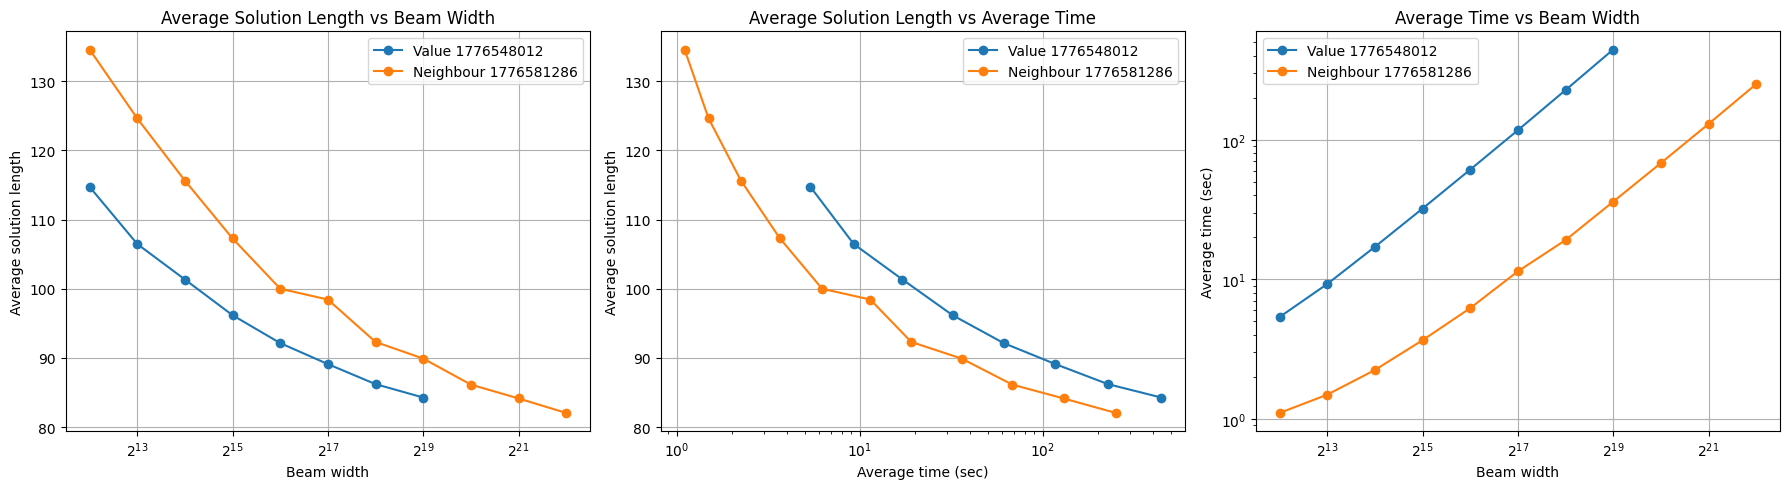

In [6]:
def plot_metric(ax, df, x_key, y_key, label):
    if df.empty:
        ax.set_title(f'No runs for {label}')
        return
    ax.plot(df[x_key], df[y_key], marker='o', label=label)
    ax.grid(True)
    ax.legend()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_metric(axes[0], value_runs, 'beam_width', 'avg_solution_length', f'Value {VALUE_MODEL_ID}')
plot_metric(axes[0], neighbour_runs, 'beam_width', 'avg_solution_length', f'Neighbour {NEIGHBOUR_MODEL_ID}')
axes[0].set_xscale('log', base=2)
axes[0].set_xlabel('Beam width')
axes[0].set_ylabel('Average solution length')
axes[0].set_title('Average Solution Length vs Beam Width')

plot_metric(axes[1], value_runs, 'avg_time_sec', 'avg_solution_length', f'Value {VALUE_MODEL_ID}')
plot_metric(axes[1], neighbour_runs, 'avg_time_sec', 'avg_solution_length', f'Neighbour {NEIGHBOUR_MODEL_ID}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Average time (sec)')
axes[1].set_ylabel('Average solution length')
axes[1].set_title('Average Solution Length vs Average Time')

plot_metric(axes[2], value_runs, 'beam_width', 'avg_time_sec', f'Value {VALUE_MODEL_ID}')
plot_metric(axes[2], neighbour_runs, 'beam_width', 'avg_time_sec', f'Neighbour {NEIGHBOUR_MODEL_ID}')
axes[2].set_xscale('log', base=2)
axes[2].set_yscale('log')
axes[2].set_xlabel('Beam width')
axes[2].set_ylabel('Average time (sec)')
axes[2].set_title('Average Time vs Beam Width')

plt.tight_layout()
plt.show()


In [7]:
summary = pd.concat(
    [
        value_runs.assign(label='value'),
        neighbour_runs.assign(label='neighbour'),
    ],
    ignore_index=True,
)
summary


,path,beam_width,compile,model_name,avg_solution_length,avg_time_sec,solved,tests,label
0,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,4096,True,p900-t000-rnd-k1000-s42,114.733333,5.378000,30,30,value
1,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,8192,True,p900-t000-rnd-k1000-s42,106.466667,9.274000,30,30,value
2,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,16384,True,p900-t000-rnd-k1000-s42,101.333333,17.122667,30,30,value
3,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,32768,True,p900-t000-rnd-k1000-s42,96.166667,32.192667,30,30,value
4,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,65536,True,p900-t000-rnd-k1000-s42,92.133333,61.228667,30,30,value
5,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,131072,True,p900-t000-rnd-k1000-s42,89.100000,117.280667,30,30,value
6,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,262144,True,p900-t000-rnd-k1000-s42,86.200000,227.414333,30,30,value
7,test_p900-t000-rnd-k1000-s42_1776548012_best_B...,524288,True,p900-t000-rnd-k1000-s42,84.266667,443.959000,30,30,value
8,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,4096,True,p900-t000-q-rnd-k1000-s42,134.600000,1.104333,30,30,neighbour
9,test_p900-t000-q-rnd-k1000-s42_1776581286_best...,8192,True,p900-t000-q-rnd-k1000-s42,124.633333,1.493000,30,30,neighbour
